# **MÓDULO 12 - Pratique**


Abaixo temos um dataframe com as seguintes informações:


**Nome:** O nome de cada indivíduo da base


**Idade:** A idade de cada um deles


**Profissão:** A atual ocupação


**Salário:** O salário registrado


**Limite de crédito:** O limite de crédito disponível para cada um dos indivíduos


**Historico_Inadimplencia:** Marco como 0 aqueles que nunca tiveram um histórico de inadimplência e como 1 aqueles que já tiveram em algum momento.


**Estado civil:** O estado civil de cada um deles


**Imovel_Proprio:** Marcado como 0 aqueles que não tem imóvel próprio e como 1 aqueles que tem.

In [2]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [3]:

data = {
    'Nome': ['Alice', 'Joao', 'Charlie', 'David', 'Eva', 'Diego', 'Denize', 'Claudio'],
    'Idade': [25, 30, 35, 40, 45, 60, 22, 24],
    'Profissão': ['Engenheiro', 'Médico', 'Professor', 'Advogado', 'Médico','Engenheiro', 'Estudante','Estudante'],
    'Salário': ['4500', '8000', '5000', '10000', '12000','15000', '1200','1500'],
    'Limite_Credito': ['2500', '4000', '4000', '1000', '10000','2000', '500','250'],
    'Historico_Inadimplencia': ['0', '0', '0', '1', '0','1', '0','1'],
    'Estado_Civil': ['Casamento', 'Casamento', 'Solteiro', 'Solteiro', 'Casamento','Solteiro', 'Solteiro','Solteiro'],
    'Imovel_Proprio': ['0', '0', '0', '1', '1','1', '0','0']
}

df = pd.DataFrame(data)
df.head(8)

,Nome,Idade,Profissão,Salário,Limite_Credito,Historico_Inadimplencia,Estado_Civil,Imovel_Proprio
0,Alice,25,Engenheiro,4500,2500,0,Casamento,0
1,Joao,30,Médico,8000,4000,0,Casamento,0
2,Charlie,35,Professor,5000,4000,0,Solteiro,0
3,David,40,Advogado,10000,1000,1,Solteiro,1
4,Eva,45,Médico,12000,10000,0,Casamento,1
5,Diego,60,Engenheiro,15000,2000,1,Solteiro,1
6,Denize,22,Estudante,1200,500,0,Solteiro,0
7,Claudio,24,Estudante,1500,250,1,Solteiro,0


A proposta da atividade é que utilizem os dados do DataFrame Data e escolham apenas 3 gráficos que ajudem vocês a identificar quais fatores são os principais impulsionadores para aqueles que tem limite de crédito alto.

Durante a exploração de vocês podem utilizar mais de 3 gráficos mas deixem na entrega final apenas os 3 mais assertivos que contenham a informação da mensagem que querem passar, fiquem livres para utilizar as bibliotecas que quiserem para os gráficos.

Justifiquem a escolha dos visuais e despertem o lado analítico de vocês com uma análise acerca do descoberto através dos gráficos. Lembrem o que aprendemos na aula, devemos ser assertivos na nossa mensagem.

## Gráfico de dispersão com a relação entre Salário e Idade

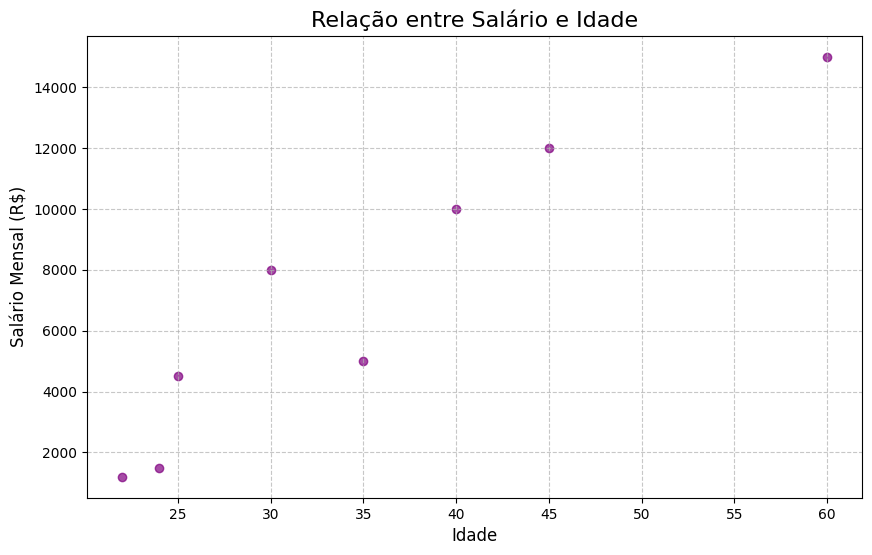

In [4]:
df['Salário'] = pd.to_numeric(df['Salário'], errors='coerce')
plt.figure(figsize=(10, 6))
plt.scatter(df['Idade'], df['Salário'], color='purple', alpha=0.7)

plt.title('Relação entre Salário e Idade', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Salário Mensal (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Gráfico de barras horizontais com os Salários por Profissão

In [5]:
salario_profissao = df.groupby('Profissão')['Salário'].mean().reset_index()

fig = px.bar(salario_profissao, x='Salário', y='Profissão', orientation='h', 
            title='Salários por Profissão',
            labels={'Salário': 'Salário Médio', 'Profissão': 'Profissão'},
            color='Salário', width=800)
fig.show()

## Gráfico de dispersão com a relação entre Salário e Limite de Crédito

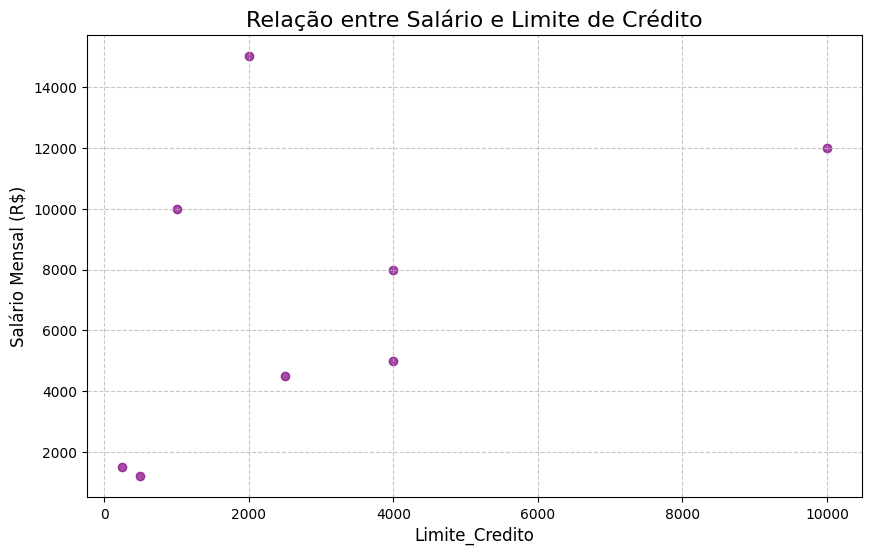

In [6]:
df['Limite_Credito'] = pd.to_numeric(df['Limite_Credito'], errors='coerce')
plt.figure(figsize=(10, 6))
plt.scatter(df['Limite_Credito'], df['Salário'], color='purple', alpha=0.7)

plt.title('Relação entre Salário e Limite de Crédito', fontsize=16)
plt.xlabel('Limite_Credito', fontsize=12)
plt.ylabel('Salário Mensal (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Gráfico de Pizza das pessoas com Histórico de Inadimplenca

In [7]:
credito_limite = df.groupby('Historico_Inadimplencia')['Limite_Credito'].mean().round(2).reset_index()

fig = px.pie(
    credito_limite,
    values='Limite_Credito',
    names='Historico_Inadimplencia',
    title='Histórico de Inadimplencia')
fig.show()

### Conclusão:
- Atravez do primeiro gráfico identificamos que pessoas mais velhas tendem a ter maior salário.
- Com o segundo gráfico observa-se que profissões como Médico, Advogado e Engenheiro são as com maiores salários.
- Enquanto no terceiro gráfico vemos que quanto maior o salário, maiores são as chesces de alto limite de crédito.
- Já no ultimo gráfico identificamos que a média de limite de crédito para pessoas com histórico de inadimplencia é R$1.083, ou seja, esse fator positivo abaixa muito as chances de limite alto de crédito.
- Portanto, pessoas mais velhas com pofissões de altos salários e sem histórico de inadimplencia tendem a receber altos limites de créditos.

## BoxPlot Limite de Crédito por Profissão

In [14]:
fig = px.box(df, x='Profissão', y='Limite_Credito', title='Limite por Profissão')
fig.show()